Saving images.jfif to images (7).jfif
Original Image:


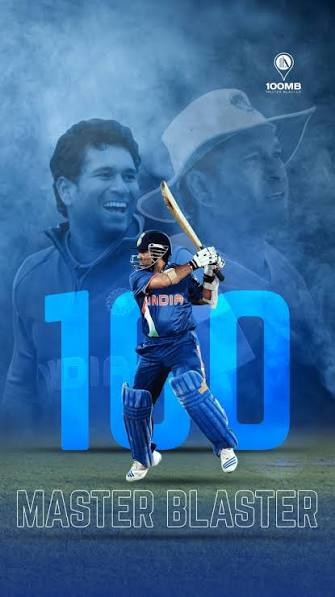

Gradient Mask:


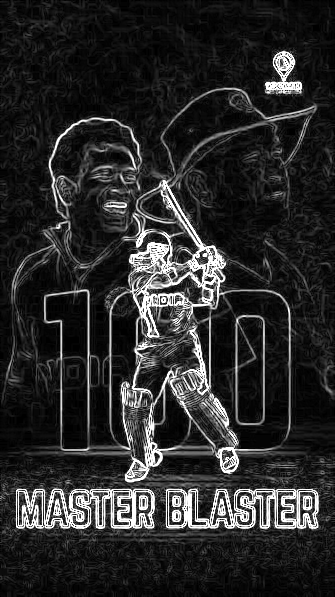

Sharpened Image using Gradient Masking:


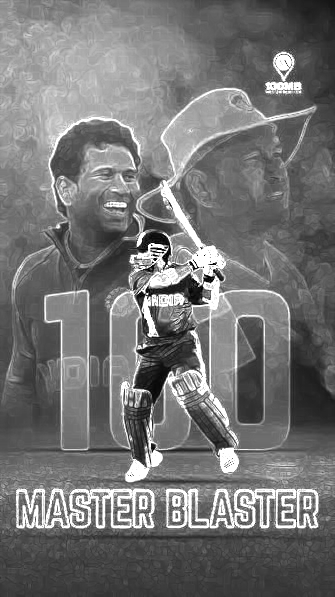

Output saved as gradient_mask_sharpened.jpg


In [9]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# Upload image
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Calculate gradients
gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

# Calculate gradient magnitude
gradient = cv2.magnitude(gx.astype(np.float32), gy.astype(np.float32))

# Convert gradient to 8-bit
gradient = cv2.convertScaleAbs(gradient)

# Create gradient mask
mask = gradient / 255.0

# Sharpen using gradient mask
sharpened = gray.astype(np.float32) + 1.5 * mask * gray.astype(np.float32)

# Convert to 8-bit
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

# Display
print("Original Image:")
cv2_imshow(image)

print("Gradient Mask:")
cv2_imshow(gradient)

print("Sharpened Image using Gradient Masking:")
cv2_imshow(sharpened)

# Save output
cv2.imwrite("gradient_mask_sharpened.jpg", sharpened)

print("Output saved as gradient_mask_sharpened.jpg")